## 08_esm2_finetune

In [1]:
# 导入库
import copy
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

In [2]:
# 路径定义与数据读取
PROJECT_ROOT = Path.cwd().parent.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
INTERIM_DIR = DATA_DIR / "interim"

RESULTS_DIR = PROJECT_ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
MODELS_DIR = RESULTS_DIR / "models"
LOGS_DIR = RESULTS_DIR / "logs"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
train_df = pd.read_csv(PROCESSED_DIR / "esm2_residue" / "train_metadata.csv")
test_df = pd.read_csv(PROCESSED_DIR / "esm2_residue" / "test_metadata.csv")

print(train_df.shape)
print(test_df.shape)
train_df.head()

(3583, 2)
(897, 2)


,sequence,label
0,SLLLNGGCKVSNYDE,1
1,DAEFRHDSGYEVHHQ,1
2,GRTGRGKPGIYRFVAPGE,1
3,ASLKPEFVQIINAKN,1
4,KCEFQDAYVLLSEKK,1


In [4]:
# 检查长度分布
train_lengths = train_df["sequence"].str.len()

print("Train max length:", train_lengths.max())
print("Train mean length:", train_lengths.mean())
print("Train min length:", train_lengths.min())

Train max length: 30
Train mean length: 16.33435668434273
Train min length: 11


In [5]:
# 从训练集里再划一个 validation set
train_sub_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=42
)

train_sub_df = train_sub_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("train_sub:", train_sub_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

train_sub: (2866, 2)
val: (717, 2)
test: (897, 2)


In [6]:
# 定义tokenizer
MODEL_NAME = "facebook/esm2_t12_35M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [7]:
# 写Dataset
class ESM2SequenceDataset(Dataset):
    def __init__(self, df):
        self.sequences = df["sequence"].tolist()
        self.labels = df["label"].astype(float).tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "sequence": self.sequences[idx],
            "label": self.labels[idx]
        }

In [8]:
# 写collate_fn
def collate_fn(batch):
    sequences = [item["sequence"] for item in batch]
    labels = torch.tensor([item["label"] for item in batch], dtype=torch.float32).unsqueeze(1)

    encoded = tokenizer(
        sequences,
        padding=True,
        truncation=True,
        max_length=64,
        return_tensors="pt"
    )

    return {
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
        "label": labels
    }

In [9]:
# 构建Dataloader
train_dataset = ESM2SequenceDataset(train_sub_df)
val_dataset = ESM2SequenceDataset(val_df)
test_dataset = ESM2SequenceDataset(test_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

In [10]:
# 检查
batch = next(iter(train_loader))
print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["label"].shape)

torch.Size([32, 28])
torch.Size([32, 28])
torch.Size([32, 1])


In [11]:
# 定义模型
class ESM2Classifier(nn.Module):
    def __init__(self, backbone, hidden_dim, dropout=0.3):
        super().__init__()
        self.backbone = backbone
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, 1)

    def masked_mean_pooling(self, hidden_states, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()
        hidden_states = hidden_states * mask
        summed = hidden_states.sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-6)
        return summed / counts

    def forward(self, input_ids, attention_mask):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        hidden = outputs.last_hidden_state
        pooled = self.masked_mean_pooling(hidden, attention_mask)
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)
        return logits

In [12]:
# 定义backbone做forzen
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

backbone = AutoModel.from_pretrained(MODEL_NAME)
hidden_dim = backbone.config.hidden_size

model = ESM2Classifier(
    backbone=backbone,
    hidden_dim=hidden_dim,
    dropout=0.3
).to(device)

# 冻结 backbone
for param in model.backbone.parameters():
    param.requires_grad = False

# 看可训练参数量
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("Trainable params:", trainable_params)
print("Total params:", total_params)

device: cpu


Loading weights:   0%|          | 0/209 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 481
Total params: 33500882


In [13]:
# 定义loss，lr等
criterion = nn.BCEWithLogitsLoss()

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

In [14]:
# 定义指标函数
def compute_metrics(y_true, y_pred, y_prob):
    return {
        "ACC": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob)
    }

In [15]:
# 定义 train / evaluate 函数
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

    return running_loss / len(loader.dataset)

In [16]:
def evaluate_on_loader(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels)

            probs = torch.sigmoid(logits)

            running_loss += loss.item() * labels.size(0)

            all_labels.extend(labels.cpu().numpy().ravel())
            all_probs.extend(probs.cpu().numpy().ravel())

    avg_loss = running_loss / len(loader.dataset)

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= 0.5).astype(int)

    metrics = compute_metrics(all_labels, all_preds, all_probs)
    return avg_loss, metrics, all_labels, all_preds, all_probs

In [17]:
# 循环训练
num_epochs = 100
best_val_auc = -1
best_model_state = None

patience = 5
counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_auc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_metrics, _, _, _ = evaluate_on_loader(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_metrics["ROC_AUC"])

    print(f"Epoch {epoch:02d}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  Val AUC:    {val_metrics['ROC_AUC']:.4f}")
    print(f"  Val F1:     {val_metrics['F1']:.4f}")
    print(f"  Val MCC:    {val_metrics['MCC']:.4f}")

    if val_metrics["ROC_AUC"] > best_val_auc:
        best_val_auc = val_metrics["ROC_AUC"]
        best_model_state = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

Epoch 01
  Train Loss: 0.6638
  Val Loss:   0.6578
  Val AUC:    0.6002
  Val F1:     0.0000
  Val MCC:    0.0000
Epoch 02
  Train Loss: 0.6554
  Val Loss:   0.6542
  Val AUC:    0.6046
  Val F1:     0.0000
  Val MCC:    0.0000
Epoch 03
  Train Loss: 0.6503
  Val Loss:   0.6504
  Val AUC:    0.6075
  Val F1:     0.0429
  Val MCC:    0.0974
Epoch 04
  Train Loss: 0.6464
  Val Loss:   0.6488
  Val AUC:    0.6086
  Val F1:     0.1267
  Val MCC:    0.1316
Epoch 05
  Train Loss: 0.6450
  Val Loss:   0.6478
  Val AUC:    0.6120
  Val F1:     0.0966
  Val MCC:    0.1421
Epoch 06
  Train Loss: 0.6430
  Val Loss:   0.6463
  Val AUC:    0.6137
  Val F1:     0.1489
  Val MCC:    0.1222
Epoch 07
  Train Loss: 0.6425
  Val Loss:   0.6460
  Val AUC:    0.6131
  Val F1:     0.1538
  Val MCC:    0.1159
Epoch 08
  Train Loss: 0.6392
  Val Loss:   0.6452
  Val AUC:    0.6156
  Val F1:     0.1693
  Val MCC:    0.1112
Epoch 09
  Train Loss: 0.6385
  Val Loss:   0.6453
  Val AUC:    0.6154
  Val F1:     0.

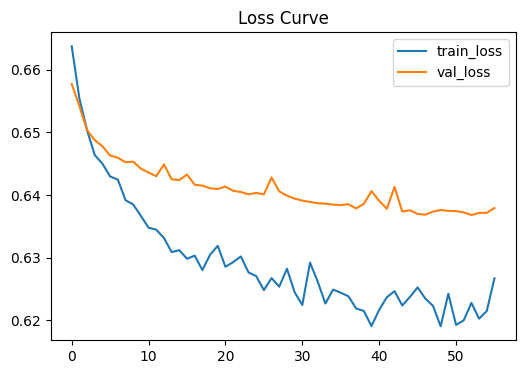

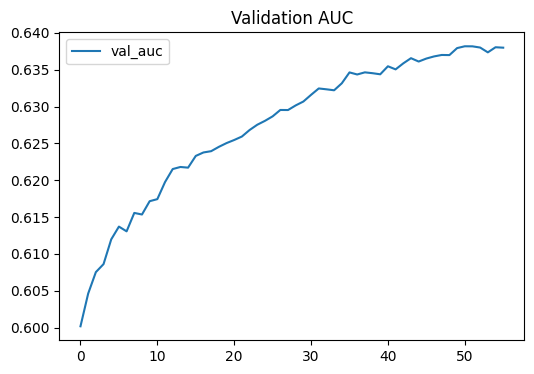

In [18]:
# 画训练曲线
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history["val_auc"], label="val_auc")
plt.legend()
plt.title("Validation AUC")
plt.show()

In [19]:
# 加载最佳模型，在测试集上评估
model.load_state_dict(best_model_state)

test_loss, test_metrics, y_true_test, y_pred_test, y_prob_test = evaluate_on_loader(
    model, test_loader, criterion, device
)

print("Test Loss:", round(test_loss, 4))
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

Test Loss: 0.6376
ACC: 0.6644
Precision: 0.6030
Recall: 0.3509
F1: 0.4436
MCC: 0.2438
ROC_AUC: 0.6467
PR_AUC: 0.5348


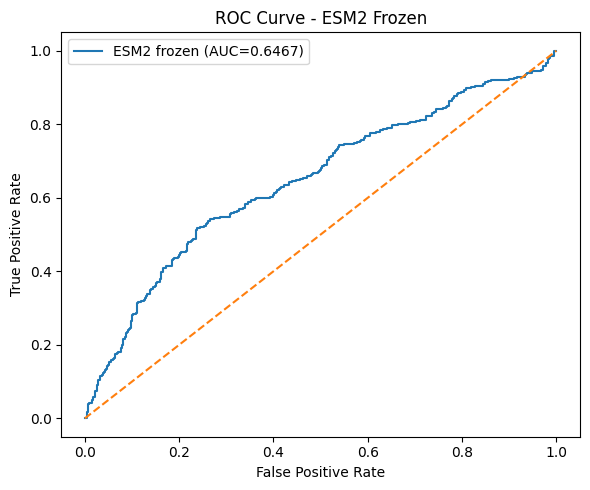

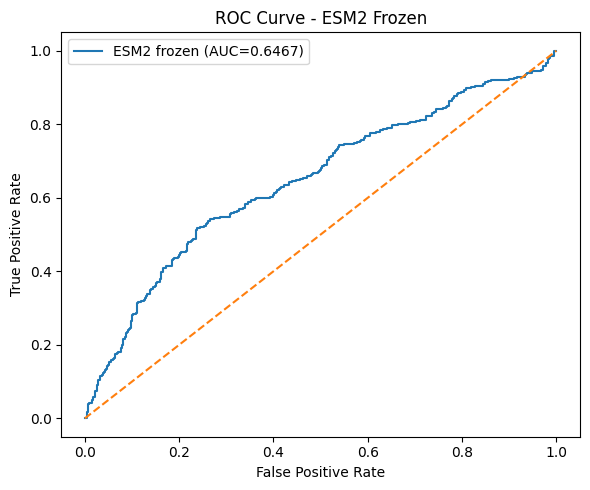

In [20]:
# 画ROC/PR曲线
fpr, tpr, _ = roc_curve(y_true_test, y_prob_test)
roc_auc = roc_auc_score(y_true_test, y_prob_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ESM2 frozen (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ESM2 Frozen")
plt.legend()
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_true_test, y_prob_test)
roc_auc = roc_auc_score(y_true_test, y_prob_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ESM2 frozen (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ESM2 Frozen")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# 保存模型与结果
torch.save(model.state_dict(), MODELS_DIR / "esm2_frozen_classifier.pt")

test_result_df = pd.DataFrame([{
    "model": "ESM2_frozen",
    **test_metrics
}])
test_result_df.to_csv(TABLES_DIR / "esm2_frozen_test_metrics.csv", index=False)

log_data = {
    "model": "ESM2_frozen",
    "model_name": MODEL_NAME,
    "best_val_auc": best_val_auc,
    "test_metrics": test_metrics
}

with open(LOGS_DIR / "esm2_frozen_log.json", "w", encoding="utf-8") as f:
    json.dump(log_data, f, ensure_ascii=False, indent=2)

print("saved.")

saved.
